<a href="https://colab.research.google.com/github/Hawkking2005/Deeplearning-analysis/blob/main/DL_173_practice_programs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **WEEK-1**(Baic perceptron and introduction to libraries)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = Net()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

for epoch in range(1000):
    output = model(X)
    loss = criterion(output, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    print(model(X))

tensor([[0.0497],
        [0.9717],
        [0.9813],
        [0.0169]])


In [ ]:
import tensorflow as tf
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss='binary_crossentropy')

model.fit(X, y, epochs=1000, verbose=0)

print(model.predict(X))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[0.10545145]
 [0.96760064]
 [0.98001647]
 [0.01810465]]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)

model = Sequential()

model.add(Dense(4, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

model.fit(X, y, epochs=1000, verbose=0)

print(model.predict(X))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[0.30877957]
 [0.76534826]
 [0.729362  ]
 [0.30877957]]


In [ ]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

weights = np.zeros(2)
bias = 0
lr = 0.1

def step(x):
    return 1 if x >= 0 else 0

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

for _ in range(100):
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = step(linear_output)
        error = y[i] - y_pred
        weights += lr * error * X[i]
        bias += lr * error

for i in range(len(X)):
    print(step(np.dot(X[i], weights) + bias))

0
0
0
1


observations:learning how to use perceptron using libraries

# **WEEK-2(Linear and non linear data and perceptron learning algorithm)**

In [ ]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])

y_and = np.array([0,0,0,1])
y_or = np.array([0,1,1,1])

def train(X, y):
    weights = np.zeros(2)
    bias = 0
    lr = 0.1

    def step(x):
        return 1 if x >= 0 else 0

    for _ in range(100):
        for i in range(len(X)):
            linear = np.dot(X[i], weights) + bias
            pred = step(linear)
            error = y[i] - pred
            weights += lr * error * X[i]
            bias += lr * error

    return weights, bias

def predict(X, weights, bias):
    def step(x):
        return 1 if x >= 0 else 0
    return [step(np.dot(x, weights) + bias) for x in X]

w_and, b_and = train(X, y_and)
w_or, b_or = train(X, y_or)

print(predict(X, w_and, b_and))
print(predict(X, w_or, b_or))

[0, 0, 0, 1]
[0, 1, 1, 1]


In [ ]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])

weights = np.zeros(2)
bias = 0
lr = 0.1

def step(x):
    return 1 if x >= 0 else 0

for _ in range(100):
    for i in range(len(X)):
        linear = np.dot(X[i], weights) + bias
        pred = step(linear)
        error = y_xor[i] - pred
        weights += lr * error * X[i]
        bias += lr * error

for i in range(len(X)):
    print(step(np.dot(X[i], weights) + bias))

1
1
0
0


In [ ]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

np.random.seed(0)

W1 = np.random.rand(2,2)
b1 = np.random.rand(1,2)

W2 = np.random.rand(2,1)
b2 = np.random.rand(1,1)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

lr = 0.5

for _ in range(10000):
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    error = y - a2

    d2 = error * sigmoid_derivative(a2)
    d1 = d2.dot(W2.T) * sigmoid_derivative(a1)

    W2 += a1.T.dot(d2) * lr
    b2 += np.sum(d2, axis=0, keepdims=True) * lr
    W1 += X.T.dot(d1) * lr
    b1 += np.sum(d1, axis=0, keepdims=True) * lr

output = sigmoid(np.dot(sigmoid(np.dot(X, W1) + b1), W2) + b2)
print(np.round(output))

[[0.]
 [1.]
 [1.]
 [0.]]


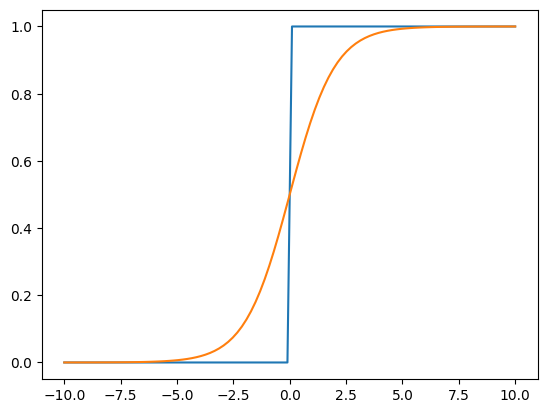

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

def step(x):
    return np.where(x >= 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

y_step = step(x)
y_sigmoid = sigmoid(x)

plt.plot(x, y_step)
plt.plot(x, y_sigmoid)
plt.show()

In [ ]:
import numpy as np

X = np.array([
    [1,1,1,0.9],
    [0,1,0,0.7],
    [1,0,1,0.8],
    [0,0,0,0.3],
    [1,1,0,0.85]
])

y = np.array([1,0,1,0,1])

def step(x):
    return 1 if x >= 0 else 0

lr = 0.1
epochs = 50

weights = np.zeros(X.shape[1])
bias = 0

for _ in range(epochs):
    for i in range(len(X)):
        linear = np.dot(X[i], weights) + bias
        pred = step(linear)
        error = y[i] - pred
        weights += lr * error * X[i]
        bias += lr * error

for i in range(len(X)):
    print(step(np.dot(X[i], weights) + bias))

1
0
1
0
1


In [ ]:
import numpy as np
from itertools import product

X = np.array([[0,0],[0,1],[1,0],[1,1]])

functions = list(product([0,1], repeat=4))

def train_perceptron(X, y):
    weights = np.zeros(2)
    bias = 0
    lr = 0.1

    def step(x):
        return 1 if x >= 0 else 0

    for _ in range(100):
        error_count = 0
        for i in range(len(X)):
            linear = np.dot(X[i], weights) + bias
            pred = step(linear)
            error = y[i] - pred
            if error != 0:
                error_count += 1
            weights += lr * error * X[i]
            bias += lr * error

        if error_count == 0:
            return True

    return False

count_learnable = 0

for f in functions:
    y = np.array(f)
    if train_perceptron(X, y):
        count_learnable += 1

print("Total Boolean Functions:", len(functions))
print("Linearly Separable:", count_learnable)
print("Not Linearly Separable:", len(functions) - count_learnable)

Total Boolean Functions: 16
Linearly Separable: 14
Not Linearly Separable: 2


In [ ]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])

y = np.array([[0],[1],[1],[0]])

np.random.seed(1)

W1 = np.random.rand(2,4)
b1 = np.random.rand(1,4)

W2 = np.random.rand(4,1)
b2 = np.random.rand(1,1)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

lr = 0.5

for _ in range(10000):
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    error = y - a2

    d2 = error * sigmoid_derivative(a2)
    d1 = d2.dot(W2.T) * sigmoid_derivative(a1)

    W2 += a1.T.dot(d2) * lr
    b2 += np.sum(d2, axis=0, keepdims=True) * lr
    W1 += X.T.dot(d1) * lr
    b1 += np.sum(d1, axis=0, keepdims=True) * lr

output = sigmoid(np.dot(sigmoid(np.dot(X, W1) + b1), W2) + b2)
print(np.round(output))

[[0.]
 [1.]
 [1.]
 [0.]]


In [ ]:
import numpy as np
from itertools import product

X = np.array(list(product([0,1],[0,1],[0,1])))

functions = list(product([0,1], repeat=8))

def train_mlp(X, y):
    np.random.seed(0)

    W1 = np.random.rand(3,5)
    b1 = np.random.rand(1,5)

    W2 = np.random.rand(5,1)
    b2 = np.random.rand(1,1)

    def sigmoid(x):
        return 1/(1+np.exp(-x))

    def sigmoid_derivative(x):
        return x*(1-x)

    lr = 0.5

    for _ in range(2000):
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)

        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        error = y - a2

        d2 = error * sigmoid_derivative(a2)
        d1 = d2.dot(W2.T) * sigmoid_derivative(a1)

        W2 += a1.T.dot(d2) * lr
        b2 += np.sum(d2, axis=0, keepdims=True) * lr
        W1 += X.T.dot(d1) * lr
        b1 += np.sum(d1, axis=0, keepdims=True) * lr

    output = sigmoid(np.dot(sigmoid(np.dot(X, W1)+b1), W2)+b2)
    return np.round(output)

count = 0

for f in functions[:20]:
    y = np.array(f).reshape(-1,1)
    out = train_mlp(X, y)
    if np.array_equal(out, y):
        count += 1

print("Tested:", 20)
print("Learned correctly:", count)

Tested: 20
Learned correctly: 20


Observations:understanding the linear and non linear data and the requirement of hidden layers

# **WEEK-3(Learning/Experimenting on mlp)**

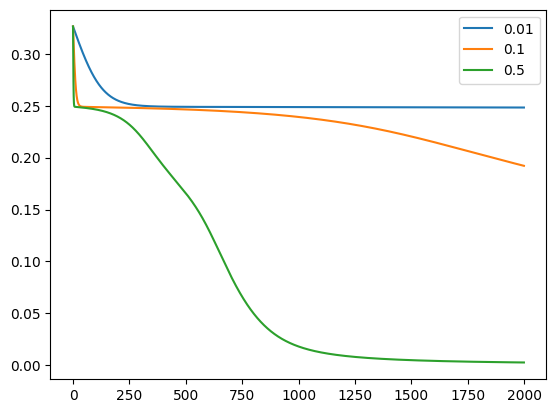

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

def train(lr):
    np.random.seed(0)

    W1 = np.random.rand(2,4)
    b1 = np.random.rand(1,4)

    W2 = np.random.rand(4,1)
    b2 = np.random.rand(1,1)

    def sigmoid(x):
        return 1/(1+np.exp(-x))

    def sigmoid_derivative(x):
        return x*(1-x)

    losses = []

    for _ in range(2000):
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)

        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        loss = np.mean((y - a2)**2)
        losses.append(loss)

        error = y - a2

        d2 = error * sigmoid_derivative(a2)
        d1 = d2.dot(W2.T) * sigmoid_derivative(a1)

        W2 += a1.T.dot(d2) * lr
        b2 += np.sum(d2, axis=0, keepdims=True) * lr
        W1 += X.T.dot(d1) * lr
        b1 += np.sum(d1, axis=0, keepdims=True) * lr

    return losses

lrs = [0.01, 0.1, 0.5]

for lr in lrs:
    losses = train(lr)
    plt.plot(losses, label=str(lr))

plt.legend()
plt.show()

In [ ]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

np.random.seed(0)

W1 = np.random.rand(2,3)
b1 = np.random.rand(1,3)

W2 = np.random.rand(3,1)
b2 = np.random.rand(1,1)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

lr = 0.1
epochs = 2000

losses = []

for _ in range(epochs):
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    loss = np.mean((y - a2)**2)
    losses.append(loss)

    error = y - a2

    d2 = error * sigmoid_derivative(a2)
    d1 = d2.dot(W2.T) * sigmoid_derivative(a1)

    W2 += a1.T.dot(d2) * lr
    b2 += np.sum(d2, axis=0, keepdims=True) * lr
    W1 += X.T.dot(d1) * lr
    b1 += np.sum(d1, axis=0, keepdims=True) * lr

print(losses[-10:])

[np.float64(0.24249920573355002), np.float64(0.24248603689397574), np.float64(0.2424728422982949), np.float64(0.24245962189550202), np.float64(0.2424463756345118), np.float64(0.242433103464159), np.float64(0.2424198053331983), np.float64(0.24240648119030467), np.float64(0.24239313098407317), np.float64(0.2423797546630192)]


In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

data = load_iris()
X = data.data
y = data.target

X = X[y != 2]
y = y[y != 2]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Perceptron(eta0=0.1, max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

1.0


In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

configs = [
    (50, 0.001),
    (100, 0.001),
    (100, 0.01),
    (150, 0.01)
]

for neurons, lr in configs:
    model = MLPClassifier(hidden_layer_sizes=(neurons,), learning_rate_init=lr, max_iter=500)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(neurons, lr, accuracy_score(y_test, y_pred))

50 0.001 0.9722222222222222
100 0.001 0.9722222222222222
100 0.01 0.9722222222222222
150 0.01 0.9722222222222222


In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

model.evaluate(X_test, y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9292 - loss: 0.2410 - val_accuracy: 0.9634 - val_loss: 0.1215
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9690 - loss: 0.1021 - val_accuracy: 0.9706 - val_loss: 0.0940
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9785 - loss: 0.0712 - val_accuracy: 0.9748 - val_loss: 0.0837
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9826 - loss: 0.0542 - val_accuracy: 0.9755 - val_loss: 0.0774
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9866 - loss: 0.0415 - val_accuracy: 0.9608 - val_loss: 0.1355
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9608 - loss: 0.1355


[0.13550691306591034, 0.9607999920845032]

observations:the dependency of model accuracy on parameters such as learning rate and about the sweet spot where the accuracy reaches maximum after which it diminishes

# **WEEK-4(Learning/experimenting on different types of gradient descent/optimisation techniques)**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


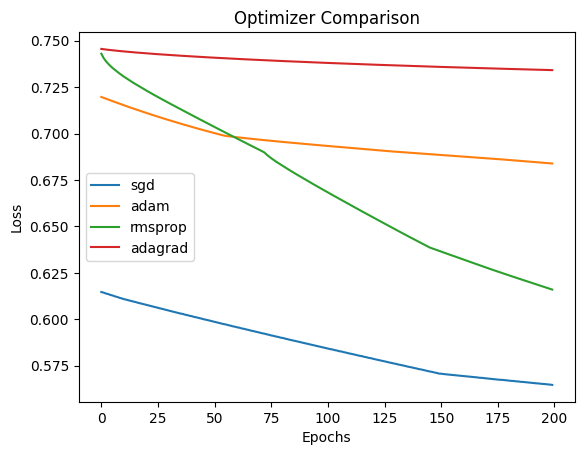

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

optimizers = ['sgd', 'adam', 'rmsprop', 'adagrad']

for opt in optimizers:
    model = Sequential()
    model.add(Dense(4, input_dim=2, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=opt, loss='binary_crossentropy')

    history = model.fit(X, y, epochs=200, verbose=0)

    plt.plot(history.history['loss'], label=opt)

plt.legend()
plt.title("Optimizer Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

observations:different tyopes work better on different data no limitations based on ther types usually the later models should work better but they act differently based on the compiatability of data

# **WEEK-5(Regularization)**

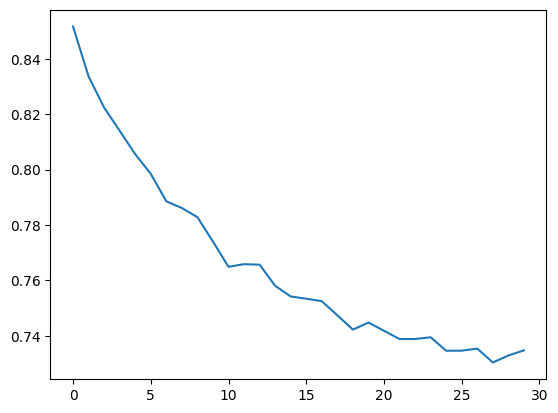

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
import numpy as np
import matplotlib.pyplot as plt

X = np.random.rand(500, 10)
y = np.random.randint(0,2,(500,1))

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=10,
                kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy')

h = model.fit(X, y, epochs=30, validation_split=0.2, verbose=0)

plt.plot(h.history['val_loss'])
plt.show()

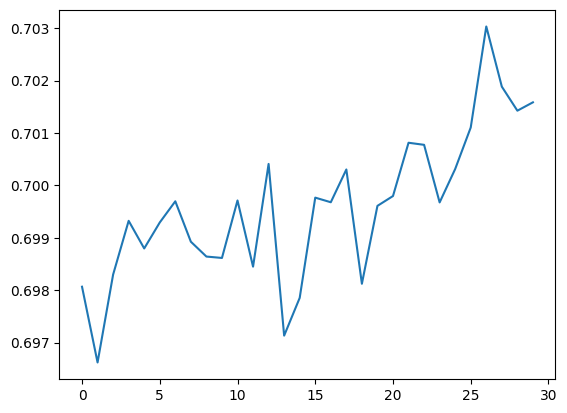

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt

X = np.random.rand(500, 10)
y = np.random.randint(0,2,(500,1))

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=10))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy')

h = model.fit(X, y, epochs=30, validation_split=0.2, verbose=0)

plt.plot(h.history['val_loss'])
plt.show()

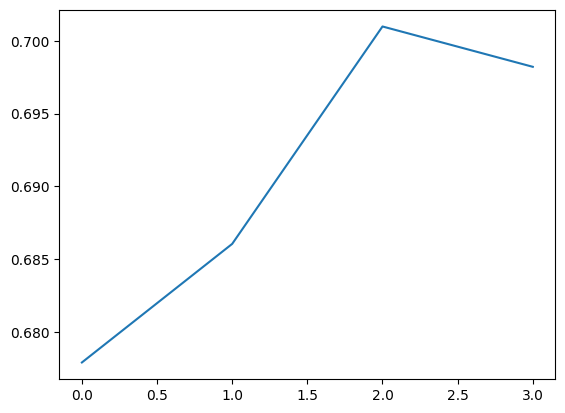

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

X = np.random.rand(500, 10)
y = np.random.randint(0,2,(500,1))

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=10))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy')

es = EarlyStopping(patience=3)

h = model.fit(X, y, epochs=50, validation_split=0.2, callbacks=[es], verbose=0)

plt.plot(h.history['val_loss'])
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


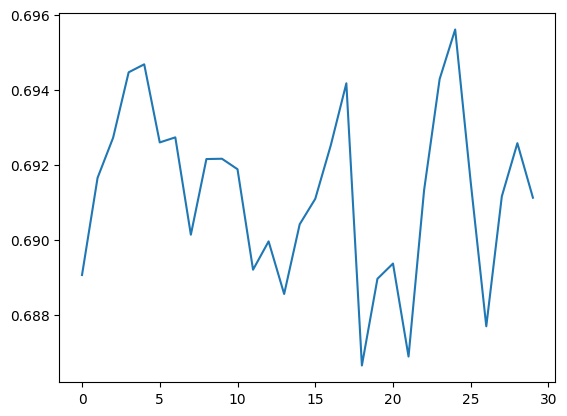

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GaussianNoise
import numpy as np
import matplotlib.pyplot as plt

X = np.random.rand(500, 10)
y = np.random.randint(0,2,(500,1))

model = Sequential()
model.add(GaussianNoise(0.1, input_shape=(10,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy')

h = model.fit(X, y, epochs=30, validation_split=0.2, verbose=0)

plt.plot(h.history['val_loss'])
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

X = np.random.rand(100, 28, 28, 1)
y = np.random.randint(0,2,100)

datagen = ImageDataGenerator(rotation_range=20,
                             zoom_range=0.2,
                             horizontal_flip=True)

datagen.fit(X)

for batch in datagen.flow(X, y, batch_size=10):
    print(batch[0].shape)
    break

(10, 28, 28, 1)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

X = np.random.rand(100, 28, 28, 1)
y = np.random.randint(0,2,100)

datagen = ImageDataGenerator(rotation_range=20,
                             zoom_range=0.2,
                             horizontal_flip=True)

datagen.fit(X)

for batch in datagen.flow(X, y, batch_size=10):
    print(batch[0].shape)
    break

(10, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

X = np.random.rand(500, 10)
y = np.random.randint(0,2,(500,1))

def build():
    model = Sequential()
    model.add(Dense(32, activation='relu', input_dim=10))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

models = []
for _ in range(3):
    m = build()
    m.fit(X, y, epochs=20, verbose=0)
    models.append(m)

preds = [m.predict(X) for m in models]
final_pred = sum(preds) / len(preds)

print((final_pred > 0.5).astype(int)[:10])

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]]


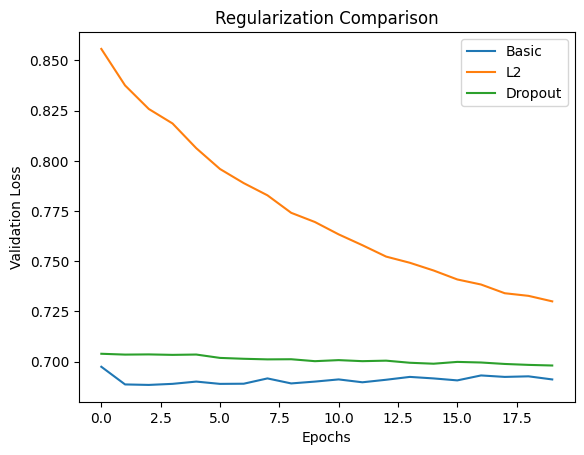

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, Flatten
from tensorflow.keras import regularizers
import numpy as np
import matplotlib.pyplot as plt

X = np.random.rand(500, 10)
y = np.random.randint(0,2,(500,1))

histories = {}

def train_basic():
    m = Sequential([Dense(64, activation='relu', input_dim=10),
                    Dense(1, activation='sigmoid')])
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m.fit(X, y, epochs=20, validation_split=0.2, verbose=0)

def train_l2():
    m = Sequential([Dense(64, activation='relu', input_dim=10,
                          kernel_regularizer=regularizers.l2(0.01)),
                    Dense(1, activation='sigmoid')])
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m.fit(X, y, epochs=20, validation_split=0.2, verbose=0)

def train_dropout():
    m = Sequential([Dense(64, activation='relu', input_dim=10),
                    Dropout(0.5),
                    Dense(1, activation='sigmoid')])
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m.fit(X, y, epochs=20, validation_split=0.2, verbose=0)

histories['Basic'] = train_basic().history['val_loss']
histories['L2'] = train_l2().history['val_loss']
histories['Dropout'] = train_dropout().history['val_loss']

for k in histories:
    plt.plot(histories[k], label=k)

plt.legend()
plt.title("Regularization Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


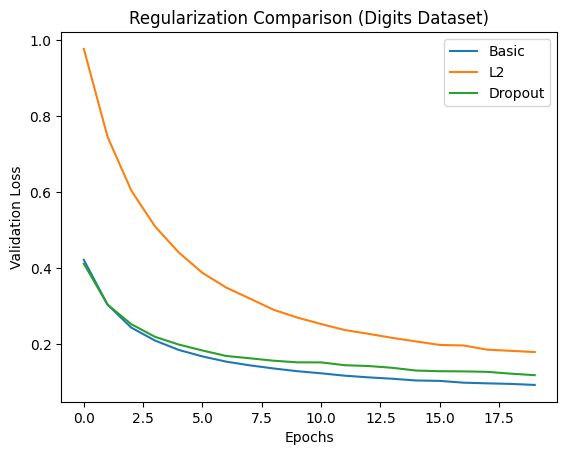

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt

data = load_digits()
X = data.data
y = data.target

y = (y > 4).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

histories = {}

def train_basic():
    m = Sequential([
        Dense(64, activation='relu', input_dim=64),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=0)

def train_l2():
    m = Sequential([
        Dense(64, activation='relu', input_dim=64,
              kernel_regularizer=regularizers.l2(0.01)),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=0)

def train_dropout():
    m = Sequential([
        Dense(64, activation='relu', input_dim=64),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy')
    return m.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=0)

histories['Basic'] = train_basic().history['val_loss']
histories['L2'] = train_l2().history['val_loss']
histories['Dropout'] = train_dropout().history['val_loss']

for k in histories:
    plt.plot(histories[k], label=k)

plt.legend()
plt.title("Regularization Comparison (Digits Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.show()

observations:the generalzation of the model is increased or made better using these methods as they remove the problem of memorising or overfitting giving out a better generalised model

# **WEEK-6(CNN)**

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1,28,28,1) / 255.0
X_test = X_test.reshape(-1,28,28,1) / 255.0

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

model.evaluate(X_test, y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9598 - loss: 0.1301 - val_accuracy: 0.9790 - val_loss: 0.0658
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9867 - loss: 0.0423 - val_accuracy: 0.9870 - val_loss: 0.0376
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9909 - loss: 0.0284 - val_accuracy: 0.9883 - val_loss: 0.0332
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9934 - loss: 0.0205 - val_accuracy: 0.9911 - val_loss: 0.0277
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9947 - loss: 0.0159 - val_accuracy: 0.9917 - val_loss: 0.0232
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9917 - loss: 0.0232


[0.023243052884936333, 0.9916999936103821]

In [ ]:
pip install tensorflow-datasets

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
(train_data, test_data), info = tfds.load(
    'oxford_iiit_pet',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)

def preprocess(image, label):
    image = tf.image.resize(image, (224,224))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess).batch(32)
test_data = test_data.map(preprocess).batch(32)

num_classes = info.features['label'].num_classes

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_data, epochs=5, validation_data=test_data)

model.evaluate(test_data)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.85G0GU_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.0340 - loss: 3.6446 - val_accuracy: 0.0462 - val_loss: 3.5530
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.0927 - loss: 3.3908 - val_accuracy: 0.0842 - val_loss: 3.4553
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.2999 - loss: 2.5895 - val_accuracy: 0.0666 - val_loss: 3.9982
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.6240 - loss: 1.3758 - val_accuracy: 0.0761 - val_loss: 5.7563
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.8237 - loss: 0.6998 - val_accuracy: 0.0788 - val_loss: 7.9846
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.0788 - loss: 7.9846


[7.98464298248291, 0.07880435138940811]

Observations:learnt ot observed the layers involved in the learning of the model the layers such as pooling layer convolutional layer and how to increase and use them in order to improve the efficiencty of the model

# **WEEK-7(Pretrained models)**

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

(train_data, test_data), info = tfds.load(
    'oxford_iiit_pet',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)

def preprocess(image, label):
    image = tf.image.resize(image, (224,224))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess).batch(32)
test_data = test_data.map(preprocess).batch(32)

num_classes = info.features['label'].num_classes

LeNet

In [ ]:
from tensorflow.keras import models, layers

model = models.Sequential()

model.add(layers.Conv2D(6, (5,5), activation='relu', input_shape=(224,224,3)))
model.add(layers.AveragePooling2D((2,2)))

model.add(layers.Conv2D(16, (5,5), activation='relu'))
model.add(layers.AveragePooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(120, activation='relu'))
model.add(layers.Dense(84, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_lenet = model.fit(train_data, epochs=3, validation_data=test_data)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.0302 - loss: 3.6841 - val_accuracy: 0.0394 - val_loss: 3.6080
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.0418 - loss: 3.5837 - val_accuracy: 0.0503 - val_loss: 3.6003
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.0958 - loss: 3.3462 - val_accuracy: 0.0720 - val_loss: 3.5731


AlexNet

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Conv2D(256, (5,5), activation='relu'))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Conv2D(384, (3,3), activation='relu'))
model.add(layers.Conv2D(384, (3,3), activation='relu'))
model.add(layers.Conv2D(256, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_alex = model.fit(train_data, epochs=3, validation_data=test_data)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.0231 - loss: 3.6131 - val_accuracy: 0.0177 - val_loss: 3.6126
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.0289 - loss: 3.6114 - val_accuracy: 0.0177 - val_loss: 3.6139
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.0296 - loss: 3.6110 - val_accuracy: 0.0177 - val_loss: 3.6151


ZF-Net

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(96, (7,7), strides=2, activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Conv2D(256, (5,5), activation='relu'))
model.add(layers.MaxPooling2D((3,3), strides=2))

model.add(layers.Conv2D(384, (3,3), activation='relu'))
model.add(layers.Conv2D(384, (3,3), activation='relu'))
model.add(layers.Conv2D(256, (3,3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_zf = model.fit(train_data, epochs=3, validation_data=test_data)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 171ms/step - accuracy: 0.0251 - loss: 4.0815 - val_accuracy: 0.0177 - val_loss: 3.6121
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.0285 - loss: 3.6116 - val_accuracy: 0.0177 - val_loss: 3.6132
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.0296 - loss: 3.6110 - val_accuracy: 0.0177 - val_loss: 3.6143


VGG16

In [ ]:
from tensorflow.keras.applications import VGG16

base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = models.Sequential([
    base,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_vgg = model.fit(train_data, epochs=3, validation_data=test_data)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 250ms/step - accuracy: 0.0462 - loss: 3.6203 - val_accuracy: 0.0652 - val_loss: 3.3794
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 230ms/step - accuracy: 0.1063 - loss: 3.0874 - val_accuracy: 0.1454 - val_loss: 3.0370
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 231ms/step - accuracy: 0.2643 - loss: 2.4547 - val_accuracy: 0.2092 - val_loss: 2.6287


ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50

base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_resnet = model.fit(train_data, epochs=3, validation_data=test_data)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 172ms/step - accuracy: 0.0265 - loss: 3.6496 - val_accuracy: 0.0408 - val_loss: 3.6084
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.0319 - loss: 3.6036 - val_accuracy: 0.0353 - val_loss: 3.5924
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.0425 - loss: 3.5869 - val_accuracy: 0.0448 - val_loss: 3.5746


GoogleNet

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

base = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_inception = model.fit(train_data, epochs=3, validation_data=test_data)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 181ms/step - accuracy: 0.7218 - loss: 1.0102 - val_accuracy: 0.8071 - val_loss: 0.6293
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.8933 - loss: 0.3276 - val_accuracy: 0.8424 - val_loss: 0.4831
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.9382 - loss: 0.1985 - val_accuracy: 0.8546 - val_loss: 0.4743


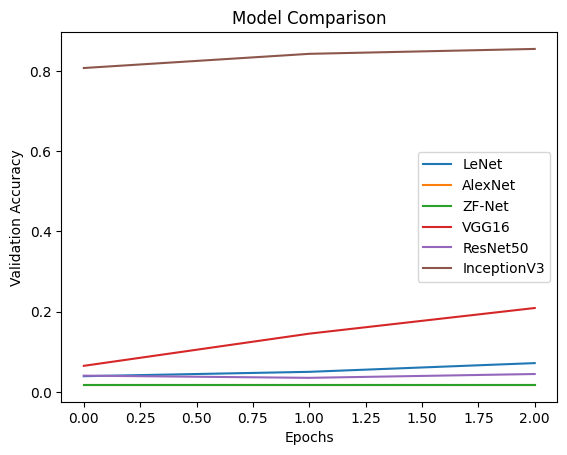

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_lenet.history['val_accuracy'], label='LeNet')
plt.plot(history_alex.history['val_accuracy'], label='AlexNet')
plt.plot(history_zf.history['val_accuracy'], label='ZF-Net')
plt.plot(history_vgg.history['val_accuracy'], label='VGG16')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50')
plt.plot(history_inception.history['val_accuracy'], label='InceptionV3')
plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.show()

observations:learnt about the improvements made over traditional models by ysimulating ther pretrained models and comparing performances inorder to understand how the efficiency management measures can be made

# **WEEK-9(visualising CNN)**

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.0357 - loss: 3.6317 - val_accuracy: 0.0516 - val_loss: 3.5434
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 0.0917 - loss: 3.4057 - val_accuracy: 0.0747 - val_loss: 3.4387
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.2948 - loss: 2.6066 - val_accuracy: 0.0747 - val_loss: 3.8096
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step


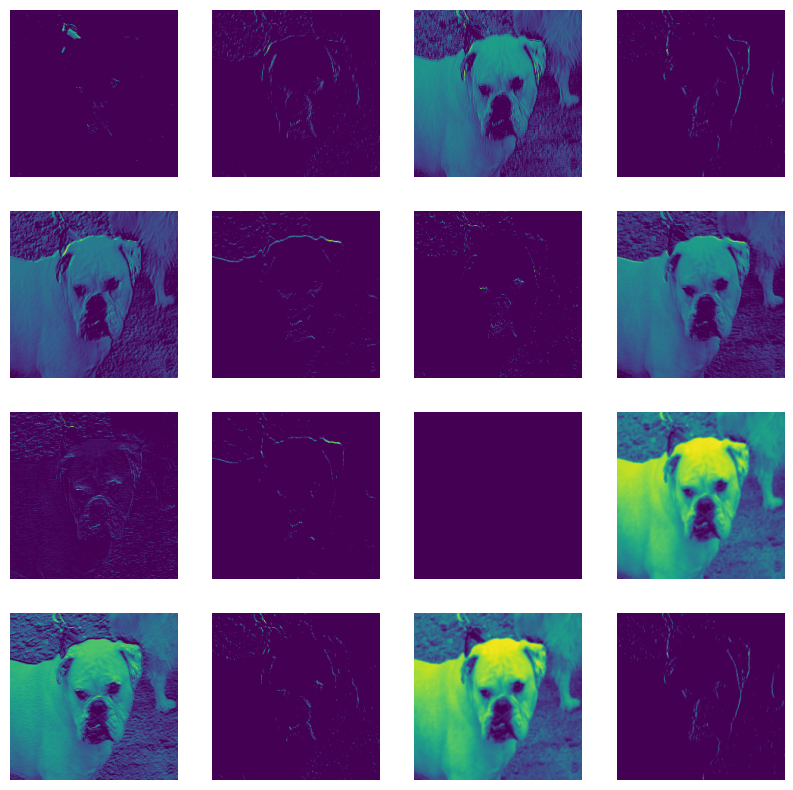

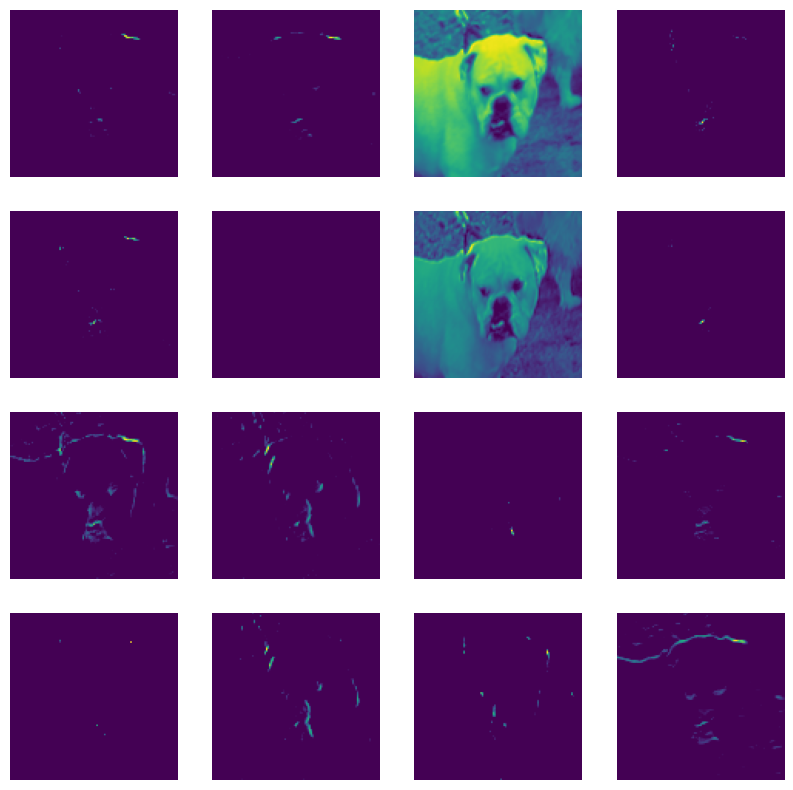

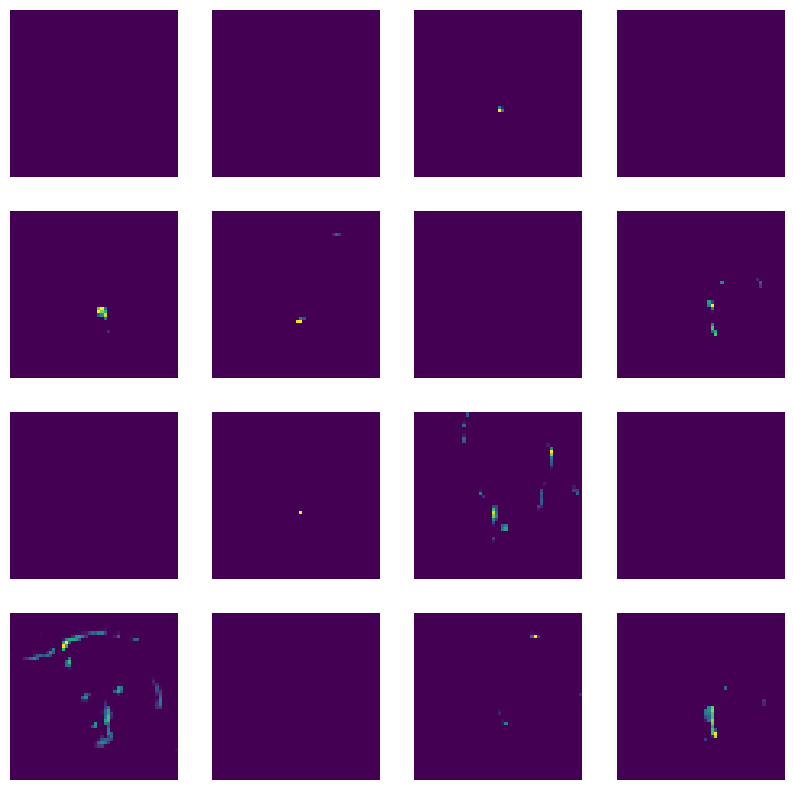

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

(train_data, test_data), info = tfds.load(
    'oxford_iiit_pet',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)

def preprocess(image, label):
    image = tf.image.resize(image, (224,224))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess).batch(32)
test_data = test_data.map(preprocess).batch(32)

num_classes = info.features['label'].num_classes

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_data, epochs=3, validation_data=test_data)

for image, label in test_data.take(1):
    sample_image = image[0:1]

inputs = tf.keras.Input(shape=(224,224,3))
x = inputs

conv_outputs = []

for layer in model.layers:
    x = layer(x)
    if 'conv' in layer.name:
        conv_outputs.append(x)

activation_model = tf.keras.Model(inputs=inputs, outputs=conv_outputs)

activations = activation_model.predict(sample_image)

for i, activation in enumerate(activations):
    num_filters = activation.shape[-1]

    plt.figure(figsize=(10,10))

    for j in range(min(num_filters, 16)):
        plt.subplot(4,4,j+1)
        plt.imshow(activation[0, :, :, j], cmap='viridis')
        plt.axis('off')

    plt.show()

observations:we understand how the model is able to highlight the required parts of the image and how it processes and analyses the importanrt parts and learns the data based on the important point odf notice

# **WEEK-10(Guided back propogation)**

Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - accuracy: 0.0285 - loss: 3.7098 - val_accuracy: 0.0272 - val_loss: 3.6094
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.0431 - loss: 3.5885 - val_accuracy: 0.0408 - val_loss: 3.5384
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.0825 - loss: 3.4435 - val_accuracy: 0.0761 - val_loss: 3.4260
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.1382 - loss: 3.2427 - val_accuracy: 0.0734 - val_loss: 3.4405
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.2086 - loss: 2.9764 - val_accuracy: 0.0897 - val_loss: 3.5114
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.3043 - loss: 2.6711 - val_accuracy: 0.1019 - val_loss: 3.4593
Epoch 7/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.3882 - loss: 2.3146 - val_accuracy: 0.1019 - val_loss: 3.6341
Epoch 8/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.4905 - loss: 1.9357 - val_accuracy: 0.

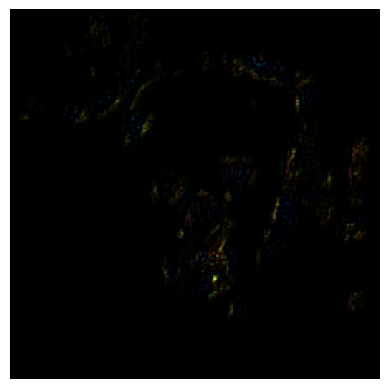

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout
(train_data, test_data), info = tfds.load(
    'oxford_iiit_pet',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)

def preprocess(image, label):
    image = tf.image.resize(image, (224,224))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess).batch(32)
test_data = test_data.map(preprocess).batch(32)

num_classes = info.features['label'].num_classes

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    return image, label

train_data = train_data.map(augment)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_data, epochs=8, validation_data=test_data)

for image, label in test_data.take(1):
    sample_image = image[0:1]

with tf.GradientTape() as tape:
    tape.watch(sample_image)
    preds = model(sample_image)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, sample_image)
guided_grads = tf.maximum(grads, 0)

guided_grads = guided_grads[0].numpy()

guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() - guided_grads.min() + 1e-8)

plt.imshow(guided_grads)
plt.axis('off')
plt.show()

observation:the output shows the major points(highlighted parts that are learnt by the model that help it differenciate tthe data it checks for such highlighted parts  and analyses data inorder to learn tyhe pattern present in the dta/dataset